In [1]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error
from collections import defaultdict
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

import joblib as jb

In [2]:
data=pd.read_csv(r"C:\Projects\football_final\data\epl_final.csv")

In [3]:
data.columns

Index(['Season', 'MatchDate', 'HomeTeam', 'AwayTeam', 'FullTimeHomeGoals',
       'FullTimeAwayGoals', 'FullTimeResult', 'HalfTimeHomeGoals',
       'HalfTimeAwayGoals', 'HalfTimeResult', 'HomeShots', 'AwayShots',
       'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners',
       'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards',
       'HomeRedCards', 'AwayRedCards'],
      dtype='str')

In [4]:
data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,...,6,5,7,4,8,10,0,2,0,0
9376,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,...,2,5,1,4,15,10,2,1,0,0
9377,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,...,2,2,1,3,18,15,2,2,0,0
9378,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,...,7,2,3,6,10,11,2,2,0,0


In [5]:
data['MatchDate']=pd.to_datetime(data['MatchDate'])

In [6]:
data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,...,6,5,7,4,8,10,0,2,0,0
9376,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,...,2,5,1,4,15,10,2,1,0,0
9377,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,...,2,2,1,3,18,15,2,2,0,0
9378,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,...,7,2,3,6,10,11,2,2,0,0


In [7]:
data = data.sort_values(by='MatchDate').reset_index(drop=True)

In [8]:
data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,...,2,2,1,3,18,15,2,2,0,0
9376,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,...,7,2,3,6,10,11,2,2,0,0
9377,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,...,6,5,7,4,8,10,0,2,0,0
9378,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,...,2,5,1,4,15,10,2,1,0,0


In [9]:
data['FullTimeResult'] = data['FullTimeResult'].map({
    'H': 0,   # Home Win
    'D': 1,   # Draw
    'A': 2    # Away Win
})

In [10]:
data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,0,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,0,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,2,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,1,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,0,2,0,H,...,8,6,6,4,21,20,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,West Ham,Tottenham,1,1,1,1,1,D,...,2,2,1,3,18,15,2,2,0,0
9376,2024/25,2025-05-04,Chelsea,Liverpool,3,1,0,1,0,H,...,7,2,3,6,10,11,2,2,0,0
9377,2024/25,2025-05-04,Brentford,Man United,4,3,0,2,1,H,...,6,5,7,4,8,10,0,2,0,0
9378,2024/25,2025-05-04,Brighton,Newcastle,1,1,1,1,0,H,...,2,5,1,4,15,10,2,1,0,0


In [11]:
data['GoalDiff'] = data['FullTimeHomeGoals'] - data['FullTimeAwayGoals']
data['ShotDiff'] = data['HomeShots'] - data['AwayShots']
data['ShotOnTargetDiff'] = data['HomeShotsOnTarget'] - data['AwayShotsOnTarget']
data['FoulDiff'] = data['HomeFouls'] - data['AwayFouls']
data['YellowDiff'] = data['HomeYellowCards'] - data['AwayYellowCards']
data['RedDiff'] = data['HomeRedCards'] - data['AwayRedCards']
data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,GoalDiff,ShotDiff,ShotOnTargetDiff,FoulDiff,YellowDiff,RedDiff
0,2000/01,2000-08-19,Charlton,Man City,4,0,0,2,0,H,...,1,2,0,0,4,9,10,1,-1,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,0,1,0,H,...,1,2,0,0,2,5,5,5,-1,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,2,1,1,D,...,5,3,1,0,-2,-10,-6,-6,2,1
3,2000/01,2000-08-19,Derby,Southampton,2,2,1,1,2,A,...,1,1,0,0,0,-7,-2,-2,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,0,2,0,H,...,1,3,0,0,2,5,2,1,-2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,West Ham,Tottenham,1,1,1,1,1,D,...,2,2,0,0,0,4,0,3,0,0
9376,2024/25,2025-05-04,Chelsea,Liverpool,3,1,0,1,0,H,...,2,2,0,0,2,6,5,-1,0,0
9377,2024/25,2025-05-04,Brentford,Man United,4,3,0,2,1,H,...,0,2,0,0,1,-2,1,-2,-2,0
9378,2024/25,2025-05-04,Brighton,Newcastle,1,1,1,1,0,H,...,2,1,0,0,0,-8,-3,5,1,0


In [12]:
le = LabelEncoder()

data['HomeTeam_enc'] = le.fit_transform(data['HomeTeam'])
data['AwayTeam_enc'] = le.fit_transform(data['AwayTeam'])

data

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeRedCards,AwayRedCards,GoalDiff,ShotDiff,ShotOnTargetDiff,FoulDiff,YellowDiff,RedDiff,HomeTeam_enc,AwayTeam_enc
0,2000/01,2000-08-19,Charlton,Man City,4,0,0,2,0,H,...,0,0,4,9,10,1,-1,0,12,26
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,0,1,0,H,...,0,0,2,5,5,5,-1,0,13,43
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,2,1,1,D,...,1,0,-2,-10,-6,-6,2,1,14,28
3,2000/01,2000-08-19,Derby,Southampton,2,2,1,1,2,A,...,0,0,0,-7,-2,-2,0,0,16,36
4,2000/01,2000-08-19,Leeds,Everton,2,0,0,2,0,H,...,0,0,2,5,2,1,-2,0,22,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,West Ham,Tottenham,1,1,1,1,1,D,...,0,0,0,4,0,3,0,0,43,40
9376,2024/25,2025-05-04,Chelsea,Liverpool,3,1,0,1,0,H,...,0,0,2,6,5,-1,0,0,13,24
9377,2024/25,2025-05-04,Brentford,Man United,4,3,0,2,1,H,...,0,0,1,-2,1,-2,-2,0,8,27
9378,2024/25,2025-05-04,Brighton,Newcastle,1,1,1,1,0,H,...,0,0,0,-8,-3,5,1,0,9,29


In [13]:
model = data[[
    'HomeTeam_enc',
    'AwayTeam_enc',
    'GoalDiff',
    'ShotDiff',
    'ShotOnTargetDiff',
    'FoulDiff',
    'YellowDiff',
    'RedDiff',
    'FullTimeResult'
]]
model

,HomeTeam_enc,AwayTeam_enc,GoalDiff,ShotDiff,ShotOnTargetDiff,FoulDiff,YellowDiff,RedDiff,FullTimeResult
0,12,26,4,9,10,1,-1,0,0
1,13,43,2,5,5,5,-1,0,0
2,14,28,-2,-10,-6,-6,2,1,2
3,16,36,0,-7,-2,-2,0,0,1
4,22,17,2,5,2,1,-2,0,0
...,...,...,...,...,...,...,...,...,...
9375,43,40,0,4,0,3,0,0,1
9376,13,24,2,6,5,-1,0,0,0
9377,8,27,1,-2,1,-2,-2,0,0
9378,9,29,0,-8,-3,5,1,0,1


In [14]:
print(model.head())
print(model.isnull().sum())

   HomeTeam_enc  AwayTeam_enc  GoalDiff  ShotDiff  ShotOnTargetDiff  FoulDiff  \
0            12            26         4         9                10         1   
1            13            43         2         5                 5         5   
2            14            28        -2       -10                -6        -6   
3            16            36         0        -7                -2        -2   
4            22            17         2         5                 2         1   

   YellowDiff  RedDiff  FullTimeResult  
0          -1        0               0  
1          -1        0               0  
2           2        1               2  
3           0        0               1  
4          -2        0               0  
HomeTeam_enc        0
AwayTeam_enc        0
GoalDiff            0
ShotDiff            0
ShotOnTargetDiff    0
FoulDiff            0
YellowDiff          0
RedDiff             0
FullTimeResult      0
dtype: int64


In [15]:
team_history = defaultdict(lambda: {'home': [], 'away': []})

In [16]:
def get_last_n_stats(matches, n=5):
    last_matches = matches[-n:]
    
    wins, draws, losses = 0, 0, 0
    goals_scored, goals_conceded = 0, 0
    
    for m in last_matches:
        goals_scored += m['scored']
        goals_conceded += m['conceded']
        
        if m['result'] == 'W':
            wins += 1
        elif m['result'] == 'D':
            draws += 1
        else:
            losses += 1
    
    total = len(last_matches)
    
    if total == 0:
        return [0]*6
    
    return [
        wins,
        draws,
        losses,
        goals_scored / total,
        goals_conceded / total,
        (wins*3 + draws) / total   # avg points
    ]

In [17]:
elo = defaultdict(lambda: 1500) 
K = 30 
def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))
print(expected_score(1500, 1500))

0.5


In [18]:
features = []

for i, row in data.iterrows():
    
    home = row['HomeTeam']
    away = row['AwayTeam']
    
    # get past stats BEFORE this match
    home_stats = get_last_n_stats(
        team_history[home]['home']
    )

    away_stats = get_last_n_stats(
        team_history[away]['away']
    )
    home_elo = elo[home]+100
    away_elo = elo[away]
    elo_diff = home_elo - away_elo
    features.append(home_stats + away_stats+[home_elo, away_elo, elo_diff])
    
    # ----- NOW update history AFTER computing features -----
    # Home team result
    if row['FullTimeHomeGoals'] > row['FullTimeAwayGoals']:
        home_result = 1
        away_result = 0
        h_res, a_res = 'W', 'L'
        
    elif row['FullTimeHomeGoals'] < row['FullTimeAwayGoals']:
        home_result = 0
        away_result = 1
        h_res, a_res = 'L', 'W'
        
    else:
        home_result = away_result = 0.5
        h_res = a_res = 'D'
    
    expected_home = expected_score(home_elo, away_elo)
    expected_away = expected_score(away_elo, home_elo)
    
    
    elo[home] += K * (home_result - expected_home)
    elo[away] += K * (away_result - expected_away)
    
    # update home team history
    team_history[home]['home'].append({
        'scored': row['FullTimeHomeGoals'],
        'conceded': row['FullTimeAwayGoals'],
        'result': home_result
    })
    
    # update away team history
    team_history[away]['away'].append({
        'scored': row['FullTimeAwayGoals'],
        'conceded': row['FullTimeHomeGoals'],
        'result': away_result
    })

In [19]:
features

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1600, 1500, 100],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1600, 1500, 100],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1600, 1500, 100],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1600, 1500, 100],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1600, 1500, 100],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1600, 1500, 100],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1600, 1500, 100],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1600, 1500, 100],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1600, 1500, 100],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1600, 1500, 100],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1589.2019499940866,
  1510.7980500059134,
  78.40389998817318],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1589.2019499940866,
  1510.7980500059134,
  78.40389998817318],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1589.2019499940866,
  1510.7980500059134,
  78.40389998817318],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  

In [20]:
feature_cols = [
    'home_wins', 'home_draws', 'home_losses',
    'home_avg_scored', 'home_avg_conceded', 'home_avg_points',
    
    'away_wins', 'away_draws', 'away_losses',
    'away_avg_scored', 'away_avg_conceded', 'away_avg_points',
    
    'home_elo', 'away_elo', 'elo_diff'
]

X = pd.DataFrame(features, columns=feature_cols)
Y = data['FullTimeResult']
print(type(team_history['Arsenal']))
print(team_history['Arsenal'].keys())

<class 'dict'>
dict_keys(['home', 'away'])


In [21]:
Y

0       0
1       0
2       2
3       1
4       0
       ..
9375    1
9376    0
9377    0
9378    1
9379    1
Name: FullTimeResult, Length: 9380, dtype: int64

In [22]:
X=X.iloc[100:]
Y=Y.iloc[100:]

In [23]:
X

,home_wins,home_draws,home_losses,home_avg_scored,home_avg_conceded,home_avg_points,away_wins,away_draws,away_losses,away_avg_scored,away_avg_conceded,away_avg_points,home_elo,away_elo,elo_diff
100,0,0,5,2.20,0.8,0.0,0,0,5,1.2,1.6,0.0,1669.065198,1503.356020,165.709178
101,0,0,4,1.75,0.5,0.0,0,0,5,1.4,2.6,0.0,1614.433921,1512.798018,101.635903
102,0,0,5,3.00,1.4,0.0,0,0,5,1.0,2.0,0.0,1604.655009,1492.493986,112.161023
103,0,0,5,1.00,1.0,0.0,0,0,5,2.0,1.4,0.0,1617.751124,1472.848233,144.902891
104,0,0,5,0.80,1.0,0.0,0,0,5,1.4,2.8,0.0,1619.626980,1431.818740,187.808240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,0,0,5,1.00,1.0,0.0,0,0,5,1.4,2.6,0.0,1628.189199,1530.596710,97.592488
9376,0,0,5,1.80,0.4,0.0,0,0,5,1.8,1.4,0.0,1789.660041,1857.761772,-68.101731
9377,0,0,5,1.00,1.2,0.0,0,0,5,1.4,1.6,0.0,1726.651141,1573.152070,153.499071
9378,0,0,5,1.80,1.8,0.0,0,0,5,1.0,2.0,0.0,1716.019994,1702.796718,13.223275


In [24]:
Y

100     0
101     0
102     0
103     0
104     0
       ..
9375    1
9376    0
9377    0
9378    1
9379    1
Name: FullTimeResult, Length: 9280, dtype: int64

In [25]:
X_train = X.loc[data['MatchDate'] < '2021-01-01']
X_test  = X.loc[data['MatchDate'] >= '2021-01-01']

Y_train = Y.loc[data['MatchDate'] < '2021-01-01']
Y_test  = Y.loc[data['MatchDate'] >= '2021-01-01']

In [26]:
X

,home_wins,home_draws,home_losses,home_avg_scored,home_avg_conceded,home_avg_points,away_wins,away_draws,away_losses,away_avg_scored,away_avg_conceded,away_avg_points,home_elo,away_elo,elo_diff
100,0,0,5,2.20,0.8,0.0,0,0,5,1.2,1.6,0.0,1669.065198,1503.356020,165.709178
101,0,0,4,1.75,0.5,0.0,0,0,5,1.4,2.6,0.0,1614.433921,1512.798018,101.635903
102,0,0,5,3.00,1.4,0.0,0,0,5,1.0,2.0,0.0,1604.655009,1492.493986,112.161023
103,0,0,5,1.00,1.0,0.0,0,0,5,2.0,1.4,0.0,1617.751124,1472.848233,144.902891
104,0,0,5,0.80,1.0,0.0,0,0,5,1.4,2.8,0.0,1619.626980,1431.818740,187.808240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,0,0,5,1.00,1.0,0.0,0,0,5,1.4,2.6,0.0,1628.189199,1530.596710,97.592488
9376,0,0,5,1.80,0.4,0.0,0,0,5,1.8,1.4,0.0,1789.660041,1857.761772,-68.101731
9377,0,0,5,1.00,1.2,0.0,0,0,5,1.4,1.6,0.0,1726.651141,1573.152070,153.499071
9378,0,0,5,1.80,1.8,0.0,0,0,5,1.0,2.0,0.0,1716.019994,1702.796718,13.223275


In [27]:
X_train

,home_wins,home_draws,home_losses,home_avg_scored,home_avg_conceded,home_avg_points,away_wins,away_draws,away_losses,away_avg_scored,away_avg_conceded,away_avg_points,home_elo,away_elo,elo_diff
100,0,0,5,2.20,0.8,0.0,0,0,5,1.2,1.6,0.0,1669.065198,1503.356020,165.709178
101,0,0,4,1.75,0.5,0.0,0,0,5,1.4,2.6,0.0,1614.433921,1512.798018,101.635903
102,0,0,5,3.00,1.4,0.0,0,0,5,1.0,2.0,0.0,1604.655009,1492.493986,112.161023
103,0,0,5,1.00,1.0,0.0,0,0,5,2.0,1.4,0.0,1617.751124,1472.848233,144.902891
104,0,0,5,0.80,1.0,0.0,0,0,5,1.4,2.8,0.0,1619.626980,1431.818740,187.808240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7660,0,0,5,0.40,1.8,0.0,0,0,5,1.6,2.6,0.0,1532.135090,1475.869427,56.265663
7661,0,0,5,0.80,1.2,0.0,0,0,5,0.6,2.2,0.0,1653.150003,1421.200668,231.949335
7662,0,0,5,1.80,0.8,0.0,0,0,5,1.4,1.8,0.0,1717.566301,1557.095475,160.470826
7663,0,0,5,0.80,1.0,0.0,0,0,5,0.4,1.0,0.0,1603.047181,1581.941221,21.105960


In [28]:
X_test

,home_wins,home_draws,home_losses,home_avg_scored,home_avg_conceded,home_avg_points,away_wins,away_draws,away_losses,away_avg_scored,away_avg_conceded,away_avg_points,home_elo,away_elo,elo_diff
7665,0,0,5,1.2,1.4,0.0,0,0,5,0.8,1.2,0.0,1736.272799,1563.569607,172.703191
7666,0,0,5,1.6,0.6,0.0,0,0,5,1.8,0.6,0.0,1832.368142,1540.146175,292.221966
7667,0,0,5,0.6,1.0,0.0,0,0,5,0.6,1.8,0.0,1587.137083,1603.222093,-16.085010
7668,0,0,5,0.4,2.8,0.0,0,0,5,0.6,0.8,0.0,1514.726921,1597.851320,-83.124398
7669,0,0,5,1.8,1.2,0.0,0,0,5,2.0,2.6,0.0,1780.773281,1493.277595,287.495686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,0,0,5,1.0,1.0,0.0,0,0,5,1.4,2.6,0.0,1628.189199,1530.596710,97.592488
9376,0,0,5,1.8,0.4,0.0,0,0,5,1.8,1.4,0.0,1789.660041,1857.761772,-68.101731
9377,0,0,5,1.0,1.2,0.0,0,0,5,1.4,1.6,0.0,1726.651141,1573.152070,153.499071
9378,0,0,5,1.8,1.8,0.0,0,0,5,1.0,2.0,0.0,1716.019994,1702.796718,13.223275


In [29]:
Y_train

100     0
101     0
102     0
103     0
104     0
       ..
7660    2
7661    0
7662    1
7663    2
7664    1
Name: FullTimeResult, Length: 7565, dtype: int64

In [30]:
Y_test

7665    2
7666    0
7667    1
7668    2
7669    0
       ..
9375    1
9376    0
9377    0
9378    1
9379    1
Name: FullTimeResult, Length: 1715, dtype: int64

In [31]:
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(7565, 15) (1715, 15)
(7565,) (1715,)


In [32]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
model.fit(X_train, Y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [33]:
Y_pred = model.predict(X_test)

In [34]:
Y_pred

array([0, 0, 2, ..., 0, 2, 0], shape=(1715,))

In [35]:
# work of scikit learn

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(confusion_matrix(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Accuracy: 0.5376093294460641
[[628  12 113]
 [258  10 121]
 [267  22 284]]
              precision    recall  f1-score   support

           0       0.54      0.83      0.66       753
           1       0.23      0.03      0.05       389
           2       0.55      0.50      0.52       573

    accuracy                           0.54      1715
   macro avg       0.44      0.45      0.41      1715
weighted avg       0.47      0.54      0.47      1715



<Axes: >

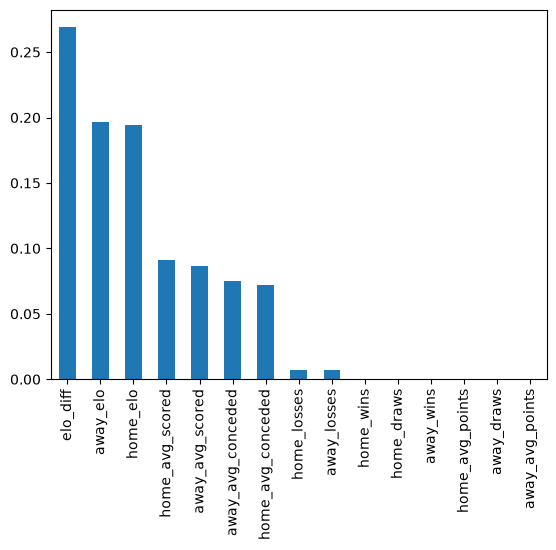

In [36]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')

In [37]:
print(Y.value_counts())

FullTimeResult
0    4256
2    2743
1    2281
Name: count, dtype: int64


In [38]:
tscv = TimeSeriesSplit(n_splits=5)
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring='accuracy',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search_xgb.fit(X,Y)

model = search_xgb.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [39]:
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

In [40]:
Y_pred

array([0, 0, 0, ..., 0, 2, 0], shape=(1715,))

Accuracy: 0.5457725947521865
[[648   2 103]
 [266   3 120]
 [278  10 285]]
              precision    recall  f1-score   support

           0       0.54      0.86      0.67       753
           1       0.20      0.01      0.01       389
           2       0.56      0.50      0.53       573

    accuracy                           0.55      1715
   macro avg       0.43      0.46      0.40      1715
weighted avg       0.47      0.55      0.47      1715



<Axes: >

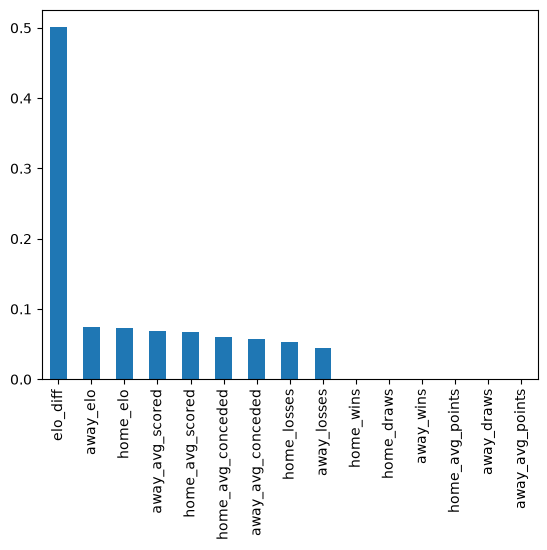

In [41]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(confusion_matrix(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')

In [42]:
accuracy_XGBoost = accuracy_score(Y_test, Y_pred)

In [43]:
print(X.columns)

Index(['home_wins', 'home_draws', 'home_losses', 'home_avg_scored',
       'home_avg_conceded', 'home_avg_points', 'away_wins', 'away_draws',
       'away_losses', 'away_avg_scored', 'away_avg_conceded',
       'away_avg_points', 'home_elo', 'away_elo', 'elo_diff'],
      dtype='str')


In [44]:
print(Y.unique())

[0 1 2]


In [45]:
y_home = data['FullTimeHomeGoals']
y_away = data['FullTimeAwayGoals']

y_home = y_home.iloc[100:]
y_away = y_away.iloc[100:]

y_home_train = y_home.loc[X_train.index]
y_home_test  = y_home.loc[X_test.index]

y_away_train = y_away.loc[X_train.index]
y_away_test  = y_away.loc[X_test.index]

xgb_reg = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

param_dist_xgb_reg = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

search_home_xgb = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_dist_xgb_reg,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search_away_xgb = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_dist_xgb_reg,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search_home_xgb.fit(X,y_home)
home_goal_model_xgb = search_home_xgb.best_estimator_

home_goal_model_xgb.fit(
    X_train,
    y_home_train
)

search_away_xgb.fit(X,y_away)
away_goal_model_xgb = search_away_xgb.best_estimator_

away_goal_model_xgb.fit(
    X_train,
    y_away_train
)

home_pred = home_goal_model_xgb.predict(X_test)

print(
    "Home Goal MAE:",
    mean_absolute_error(
        y_home_test,
        home_pred
    )
)

away_pred = away_goal_model_xgb.predict(X_test)

print(
    "Away Goal MAE:",
    mean_absolute_error(
        y_away_test,
        away_pred
    )
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Home Goal MAE: 0.9780781865119934
Away Goal MAE: 0.9005072712898254


In [46]:
mae = [mean_absolute_error(y_home_test, home_pred), mean_absolute_error(y_away_test, away_pred)]

In [47]:
import pandas as pd

def create_match_features_elo(home_team, away_team):

    home_stats = get_last_n_stats(
        team_history[home_team]['home']
    )

    away_stats = get_last_n_stats(
        team_history[away_team]['away']
    )

    home_elo = elo[home_team] + 100
    away_elo = elo[away_team]

    elo_diff = home_elo - away_elo

    features = (
        home_stats
        + away_stats
        + [home_elo, away_elo, elo_diff]
    )

    return pd.DataFrame(
        [features],
        columns=feature_cols
    )

def predict_match_xgb(home_team, away_team):

    if home_team not in team_history:
        print(f"{home_team} not found")
        return

    if away_team not in team_history:
        print(f"{away_team} not found")
        return

    features = create_match_features_elo(
        home_team,
        away_team
    )

    probs = model.predict_proba(features)[0]

    home_win_prob = probs[0]
    draw_prob = probs[1]
    away_win_prob = probs[2]

    pred = model.predict(features)[0]

    outcome_map = {
        0: "Home Win",
        1: "Draw",
        2: "Away Win"
    }

    home_goals = home_goal_model_xgb.predict(features)[0]
    away_goals = away_goal_model_xgb.predict(features)[0]

    score_home = max(0, round(home_goals))
    score_away = max(0, round(away_goals))

    confidence = max(probs) * 100

    print("\n" + "=" * 50)
    print(f"HOME : {home_team}")
    print(f"AWAY : {away_team}")
    print("=" * 50)

    print("\nWin Probabilities")

    print(f"Home Win : {home_win_prob*100:.2f}%")
    print(f"Draw     : {draw_prob*100:.2f}%")
    print(f"Away Win : {away_win_prob*100:.2f}%")

    print("\nPredicted Outcome")
    print(outcome_map[pred])

    print(f"\nConfidence: {confidence:.2f}%")

    print("\nExpected Goals")

    print(f"{home_team}: {home_goals:.2f}")
    print(f"{away_team}: {away_goals:.2f}")

    print(f"\nPredicted Score: {score_home}-{score_away}")
    
predict_match_xgb(
    "Arsenal",
    "Chelsea"
)
predict_match_xgb(
    "Liverpool",
    "Man City"
)


HOME : Arsenal
AWAY : Chelsea

Win Probabilities
Home Win : 48.08%
Draw     : 30.11%
Away Win : 21.81%

Predicted Outcome
Home Win

Confidence: 48.08%

Expected Goals
Arsenal: 1.63
Chelsea: 0.98

Predicted Score: 2-1

HOME : Liverpool
AWAY : Man City

Win Probabilities
Home Win : 54.43%
Draw     : 21.03%
Away Win : 24.54%

Predicted Outcome
Home Win

Confidence: 54.43%

Expected Goals
Liverpool: 1.66
Man City: 1.05

Predicted Score: 2-1


In [48]:
def predict_match_xgb_st(home_team, away_team):
    features_st = create_match_features_elo(home_team, away_team)

    # Classification probabilities
    probs_st = model.predict_proba(features_st)[0]

    home_win_prob_st = round(probs_st[0], 2)
    draw_prob_st = round(probs_st[1], 2)
    away_win_prob_st = round(probs_st[2], 2)

    # Goal predictions
    home_goals_st = home_goal_model_xgb.predict(features_st)[0]
    away_goals_st = away_goal_model_xgb.predict(features_st)[0]

    # Make score realistic
    predicted_home_st = max(0, round(home_goals_st))
    predicted_away_st = max(0, round(away_goals_st))

    return[
        home_win_prob_st,
        draw_prob_st,
        away_win_prob_st,
        predicted_home_st,
        predicted_away_st
    ]

In [49]:
jb.dump(model, r"C:\Projects\football_final\training\dumped_models_vars\xgb_model.joblib")
jb.dump(home_goal_model_xgb, r"C:\Projects\football_final\training\dumped_models_vars\xgb_home_goal_model.joblib")
jb.dump(away_goal_model_xgb, r"C:\Projects\football_final\training\dumped_models_vars\xgb_away_goal_model.joblib")

jb.dump(accuracy_XGBoost, r"C:\Projects\football_final\training\dumped_models_vars\xgb_acc.joblib")

['C:\\Projects\\football_final\\training\\dumped_models_vars\\xgb_acc.joblib']

In [50]:
team_history_xgb = dict(team_history)

In [51]:
jb.dump(team_history_xgb, r"C:\Projects\football_final\training\dumped_models_vars\team_history_xgb.joblib")

['C:\\Projects\\football_final\\training\\dumped_models_vars\\team_history_xgb.joblib']

In [52]:
jb.dump(mae, r"C:\Projects\football_final\training\dumped_models_vars\mae_xgb.joblib")

['C:\\Projects\\football_final\\training\\dumped_models_vars\\mae_xgb.joblib']